# Task 2.1: Dataset Selection and Setup

**Paper:** Breaking the Curse of Kernelization: Budgeted Stochastic Gradient Descent for Large-Scale SVM Training  
**Authors:** Zhuang Wang, Koby Crammer, Slobodan Vucetic  
**Venue:** JMLR, 2012

---

## Dataset Choice: 2D Checkerboard (Synthetic)

For reproducing the BPegasos algorithm, I chose the **2D Checkerboard** dataset. This is a synthetic binary classification task where the unit square $[0,1]^2$ is divided into a grid of cells and alternating cells receive positive and negative labels. The Checkerboard is used extensively throughout the original paper (Section 7, Tables 3 through 6, Figures 2, 4, 5, and 6), making it the natural first choice for reproduction since I can directly compare my results against the paper's.

Beyond being used in the paper, the Checkerboard is genuinely a good testbed for kernel methods. The alternating pattern creates a highly non-linear decision boundary that is impossible for a linear classifier to capture. An RBF kernel is needed to achieve reasonable accuracy, which is exactly the regime where BSGD is designed to work. The regularity of the pattern also makes it easy to visually verify whether the learned classifier is capturing the intended structure.

I generate 2,000 samples on a 4x4 grid. This is much smaller than the paper's experiments, which scale up to 10 million Checkerboard points, but is appropriate for CPU-based reproduction within the time constraints of this assignment. The smaller size means that absolute accuracy values will differ from the paper, but the qualitative behaviour of the algorithm (such as the ordering of strategies and the effect of the budget) should remain observable.

**Limitations compared to the paper's dataset:** The paper uses up to 10 million examples specifically to demonstrate the scalability advantage of BPegasos over unbounded methods. With 2,000 samples, even unbounded Pegasos runs quickly, so the training time comparison is less meaningful. The paper also evaluates on 14 other datasets (USPS, Letter, Covertype, Adult, etc.), while I focus only on Checkerboard.

## Preprocessing

Features are generated uniformly in $[0,1]^2$, so they are already normalised and no further standardisation is applied. Labels are encoded as $\{-1, +1\}$ to match the hinge loss formulation in the paper. I use a stratified 70/30 train/test split with a fixed random seed for reproducibility.

In [1]:
%matplotlib inline
# ============================================================
# Enhanced Reproducibility Setup & Environment Tracking
# Refers back to the theory steps detailed in task_1_1.ipynb
# ============================================================
import numpy as np
import matplotlib as mpl
import sklearn
import sys
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("=== Environment Set up for Reproducibility ===")
print(f"Python Version: {sys.version.split()[0]}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {mpl.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"Global Random Seed: {RANDOM_SEED}")
print("==============================================")
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import time
import matplotlib.pyplot as plt


=== Environment Set up for Reproducibility ===
Python Version: 3.13.1
NumPy Version: 2.2.3
Matplotlib Version: 3.10.7
Scikit-Learn Version: 1.7.2
Global Random Seed: 42


In [2]:
import matplotlib.pyplot as plt
import os, time
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

def generate_checkerboard(n_samples=2000, grid_size=4, noise=0.0, random_state=42):
    """
    Generate a 2D checkerboard binary classification dataset.
    
    Points are sampled uniformly in [0,1]^2 and assigned labels based
    on a grid: cells where (row + col) is even get label +1, others get -1.
    
    This is the same type of dataset described in Section 7 of the paper.
    """
    rng = np.random.RandomState(random_state)
    X = rng.uniform(0, 1, size=(n_samples, 2))
    
    # Determine which cell each point belongs to
    cell_x = np.floor(X[:, 0] * grid_size).astype(int)
    cell_y = np.floor(X[:, 1] * grid_size).astype(int)
    
    # Checkerboard pattern: +1 if (cell_x + cell_y) is even, -1 otherwise
    y = np.where((cell_x + cell_y) % 2 == 0, 1, -1)
    
    if noise > 0:
        X += rng.normal(0, noise, size=X.shape)
    
    return X, y

The `generate_checkerboard` function creates a synthetic dataset by uniformly sampling 2D points and assigning binary labels based on a grid pattern. This is the same type of dataset described in Section 7 of the paper, where it is used as the primary benchmark for evaluating BPegasos.

In [3]:
# Generate the dataset
X, y = generate_checkerboard(n_samples=2000, grid_size=4, noise=0.0, random_state=RANDOM_SEED)

print(f"Dataset shape: X = {X.shape}, y = {y.shape}")
print(f"Class distribution: +1 = {np.sum(y == 1)}, -1 = {np.sum(y == -1)}")
print(f"Feature range: [{X.min():.4f}, {X.max():.4f}]")
print(f"Labels: {np.unique(y)}")

Dataset shape: X = (2000, 2), y = (2000,)
Class distribution: +1 = 1014, -1 = 986
Feature range: [0.0000, 0.9997]
Labels: [-1  1]


Saved: results/checkerboard_dataset.png


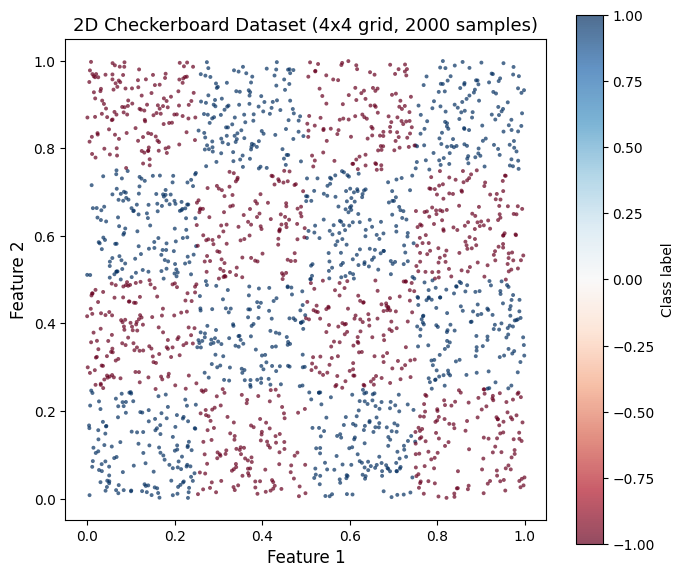

In [4]:
import matplotlib.pyplot as plt
import os

os.makedirs('results', exist_ok=True)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', s=8, alpha=0.7, edgecolors='none')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('2D Checkerboard Dataset (4x4 grid, 2000 samples)', fontsize=13)
plt.colorbar(scatter, ax=ax, label='Class label')
ax.set_aspect('equal')
plt.tight_layout()

fig.savefig('results/checkerboard_dataset.png', dpi=150, bbox_inches='tight')
print("Saved: results/checkerboard_dataset.png")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train class balance: +1 = {np.sum(y_train == 1)}, -1 = {np.sum(y_train == -1)}")
print(f"Test class balance:  +1 = {np.sum(y_test == 1)}, -1 = {np.sum(y_test == -1)}")

Training set: 1400 samples
Test set:     600 samples
Train class balance: +1 = 710, -1 = 690
Test class balance:  +1 = 304, -1 = 296


The stratified train/test split ensures that the class proportions are preserved in both subsets. Since the original dataset is balanced (equal numbers of +1 and -1 labels by construction of the checkerboard), both the training and test sets should be approximately balanced as well.